The file `amazon-meta.txt` contains product information with these attributes:
- **id**: Numeric identifier
- **ASIN**: Amazon Standard Identification Number
- **title**: Product title
- **group**: Product category (Book, Music, DVD, Video)
- **salesrank**: Sales ranking
- **similar**: Related products (by ASIN) (È Amazon stessa che definisce la similarità, tramite il suo algoritmo interno di "Customers who bought this also bought".)
- **categories**: Product categories
- **reviews**: User reviews with ratings

---

## 1. Exploratory Data Analysis of the Graph

In queesta sezione configuro la spark session

In [2]:
# inizialze Spark Session
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

# spark session settings
# graphframes for the graph analysis
# 8 gb of driver memory to avoid OOM
spark = SparkSession.builder \
    .master("local[8]") \
    .appName("AmazonGraphAnalysis") \
    .config("spark.jars.packages", "graphframes:graphframes:0.8.3-spark3.4-s_2.12") \
    .config("spark.driver.memory", "6g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .getOrCreate()

sc = spark.sparkContext 
sc.setLogLevel("WARN") # reduce log level too avoid too much log output
# KyroSerializer is more efficient than the default Java serializer, especially for complex objects like GraphFrames. It can significantly reduce memory usage and improve performance when working with large datasets and graph computations.

:: loading settings :: url = jar:file:/opt/anaconda3/envs/DataMining/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /Users/filippostanghellini/.ivy2/cache
The jars for the packages stored in: /Users/filippostanghellini/.ivy2/jars
graphframes#graphframes added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-b15709b5-0ce1-413b-8b4c-269086398a60;1.0
	confs: [default]
	found graphframes#graphframes;0.8.3-spark3.4-s_2.12 in spark-packages
	found org.slf4j#slf4j-api;1.7.16 in central
:: resolution report :: resolve 75ms :: artifacts dl 2ms
	:: modules in use:
	graphframes#graphframes;0.8.3-spark3.4-s_2.12 from spark-packages in [default]
	org.slf4j#slf4j-api;1.7.16 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   2   |   0   |   0   |   0   ||   2   |   0   |
	------

**nodes.csv** e **edges_ids.txt** sono pre processati da amazon-meta.txt.

**Se i due dataset non sono presenti in data:**

1- Ricontrollare di avere installato **glf**, e correttamente scaricato il dataset.

2- Re runnare il norebook riguardante la pipeline di pre processing.

In [3]:
# Upload data
nodes_df = spark.read.csv("data/nodes.csv", header=True, inferSchema=True)
nodes_df = nodes_df.withColumn("id", F.col("id").cast("integer"))
nodes_df = nodes_df.withColumn("salesrank", F.col("salesrank").cast("integer"))

# Upload edges 
edges_df = spark.read.csv("data/edges_ids.txt", sep="\t", schema="src STRING, dst STRING")
edges_df = edges_df.withColumn("src", F.col("src").cast("integer"))
edges_df = edges_df.withColumn("dst", F.col("dst").cast("integer"))

# Upload ratings
ratings_df = spark.read.csv("data/ratings.csv", header=True, inferSchema=True)
ratings_df = ratings_df.withColumn("product_id", F.col("product_id").cast("integer"))
ratings_df = ratings_df.withColumn("rating", F.col("rating").cast("float"))
ratings_df = ratings_df.na.drop()

Controllo di debug per verificare che non vi siano problemi nella pipeline di pre processing.

In [4]:
# nodes, edges, ratings overview

print("Total nodes:", nodes_df.count())
nodes_df.show(5, truncate=False) # expample of nodes    

print("Total edges:", edges_df.count())
edges_df.show(5, truncate=False) # example of edges, where src is the source and dst is the destination of the edge

print("Total ratings:", ratings_df.count()) # debug

Total nodes: 548552
+---+----------+------------------------------------------------------------+-----+---------+
|id |asin      |title                                                       |group|salesrank|
+---+----------+------------------------------------------------------------+-----+---------+
|0  |0771044445|null                                                        |null |null     |
|1  |0827229534|Patterns of Preaching: A Sermon Sampler                     |Book |396585   |
|2  |0738700797|Candlemas: Feast of Flames                                  |Book |168596   |
|3  |0486287785|World War II Allied Fighter Planes Trading Cards            |Book |1270652  |
|4  |0842328327|Life Application Bible Commentary: 1 and 2 Timothy and Titus|Book |631289   |
+---+----------+------------------------------------------------------------+-----+---------+
only showing top 5 rows

Total edges: 1231439
+---+------+
|src|dst   |
+---+------+
|1  |161555|
|1  |244916|
|1  |118052|
|1  |44423

Total ratings: 7593244


In [5]:
# groups distribution
group_counts = nodes_df.groupBy("group").count().orderBy(F.desc("count"))
group_counts.show(5, truncate=False)

+-----+------+
|group|count |
+-----+------+
|Book |393363|
|Music|103040|
|Video|26119 |
|DVD  |19823 |
|null |5868  |
+-----+------+
only showing top 5 rows



In [6]:
# out-degree distribution
out_degrees = edges_df.groupBy("src").count().withColumnRenamed("count", "out_degree")

# out-degree distribution statistics (table)
out_degrees.select(
    F.min("out_degree").alias("min"),
    F.max("out_degree").alias("max"),
    F.avg("out_degree").alias("mean"),
    F.median("out_degree").alias("median")
).show()

# products with most co-purchased products (top 10)
out_degrees.orderBy(F.desc("out_degree")).limit(10).show(truncate=False)

# In this case i don't show the full list because 5 is the max out degree (not informative)

+---+---+------------------+------+
|min|max|              mean|median|
+---+---+------------------+------+
|  1|  5|3.4058390284511586|   4.0|
+---+---+------------------+------+

+---+----------+
|src|out_degree|
+---+----------+
|304|5         |
|199|5         |
|673|5         |
|575|5         |
|340|5         |
|251|5         |
|265|5         |
|26 |5         |
|362|5         |
|272|5         |
+---+----------+



In [7]:
# in-degree distribution
in_degrees = edges_df.groupBy("dst").count().withColumnRenamed("count", "in_degree")

in_degrees.select(
    F.min("in_degree").alias("min"),
    F.max("in_degree").alias("max"),
    F.avg("in_degree").alias("mean"),
    F.median("in_degree").alias("median")
).show()

# products with most in-degrees (top 10)
in_degrees.orderBy(F.desc("in_degree")).limit(10).show(truncate=False)

# script used to create the table with names of the products with most in-degrees (top 10)
# products with most in-degrees (top 10) took from in_degree table
target_dst = [548091, 458358, 222074, 199628, 515301, 291117, 502784, 296016, 239107, 436020]

table_with_names = (
    in_degrees
    .filter(F.col("dst").isin(target_dst))
    .join(
        nodes_df.select(
            F.col("id").alias("dst"),
            F.col("title").alias("product_name")
        ),
        on="dst",
        how="left"
    )
    .select("dst", "in_degree", "product_name")
    .orderBy(F.desc("in_degree"))
)

table_with_names.show(truncate=False)


+---+---+-----------------+------+
|min|max|             mean|median|
+---+---+-----------------+------+
|  1|549|5.190098075164267|   3.0|
+---+---+-----------------+------+

+------+---------+
|dst   |in_degree|
+------+---------+
|548091|549      |
|458358|324      |
|222074|256      |
|199628|230      |
|515301|228      |
|291117|219      |
|502784|216      |
|296016|212      |
|239107|205      |
|436020|197      |
+------+---------+

+------+---------+---------------------------------------------------------------------------------------------------------------------------------------+
|dst   |in_degree|product_name                                                                                                                           |
+------+---------+---------------------------------------------------------------------------------------------------------------------------------------+
|548091|549      |Laura                                                                     

In [8]:
# Ratings overview

ratings_df.select(
    F.count("rating").alias("count"),
    F.min("rating").alias("min"),
    F.max("rating").alias("max"),
    F.avg("rating").alias("mean"),
    F.stddev("rating").alias("std")
).show()

print("Distribution of ratings") # debug
ratings_df.groupBy("rating").count().orderBy("rating").show(truncate=False)

print("Users with most reviews (top 10)") # debug
ratings_df.groupBy("user_id").count().orderBy(F.desc("count")).limit(10).show(truncate=False)

print("Products with most reviews (top 10)") # debug
ratings_df.groupBy("product_id").count().orderBy(F.desc("count")).limit(10).show(truncate=False)

+-------+---+---+-----------------+-----------------+
|  count|min|max|             mean|              std|
+-------+---+---+-----------------+-----------------+
|7593244|1.0|5.0|4.178371720966691|1.250067720807292|
+-------+---+---+-----------------+-----------------+

Distribution of ratings


+------+-------+
|rating|count  |
+------+-------+
|1.0   |583766 |
|2.0   |415312 |
|3.0   |627917 |
|4.0   |1401990|
|5.0   |4564259|
+------+-------+

Users with most reviews (top 10)


+--------------+------+
|user_id       |count |
+--------------+------+
|ATVPDKIKX0DER |945065|
|A3UN6WX5RRO2AG|201770|
|A14OJS0VWMOSWO|9795  |
|A2NJO6YE954DBH|6324  |
|AFVQZQ8PW0L   |5441  |
|A9Q28YTLYREO7 |4296  |
|A1K1JW1C5CUSUZ|3576  |
|AU8552YCOO5QX |2864  |
|A3LZGLA88K0LA0|2276  |
|A20EEWWSFMZ1PN|2181  |
+--------------+------+

Products with most reviews (top 10)
+----------+-----+
|product_id|count|
+----------+-----+
|91158     |4995 |
|6130      |4995 |
|258380    |4995 |
|23792     |4995 |
|429348    |4995 |
|211463    |4995 |
|526761    |4995 |
|250879    |4995 |
|428073    |4995 |
|546259    |4995 |
+----------+-----+



---

<a id='section-2'></a>
## 2. PageRank con GraphFrames

Calcolo dell'importanza dei nodi nel grafo utilizzando l'algoritmo PageRank.

In [9]:
# GraphFrame creation

from graphframes import GraphFrame # import check

# correct column name for vertices (id)
vertices_df = nodes_df.withColumnRenamed("id", "id")

# create the GraphFrame
g = GraphFrame(vertices_df, edges_df)

print("Vertices:", g.vertices.count()) # check vertices count
print("Edges:", g.edges.count()) # check edges count

Vertices: 548552
Edges: 1231439


In [10]:
# PageRank calculation

# PageRank with reset probability = 0.15 (standard)
# In this case maxIter is set to 100 to ensure convergence, but it can be adjusted based on the size of the graph and computational resources.
# resetProbility is set to a standard value of 0.15, which means that there is a 15% chance that the random surfer will jump to a random node instead of following an outgoing edge. 
# This helps to ensure that the PageRank algorithm converges even in cases where there are sink nodes (nodes with no outgoing edges) or disconnected components in the graph.
pagerank_results = g.pageRank(resetProbability=0.15, maxIter=100)
print("PageRank done")

# Unisci risultati con attributi nodi
pagerank_with_info = pagerank_results.vertices.select(
    "id", "asin", "title", "group", "salesrank", "pagerank"
)

pagerank_with_info.printSchema() # debug

PageRank done
root
 |-- id: integer (nullable = true)
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- group: string (nullable = true)
 |-- salesrank: integer (nullable = true)
 |-- pagerank: double (nullable = true)



Salesrank misura la popolarità assoluta, PageRank misura la centralità nei pattern di co-acquisto relazionale.

In [11]:
# top 20 products by PageRank

print("TOP 20 PRODUCTS BY PAGERANK")
top_pagerank = pagerank_with_info.orderBy(F.desc("pagerank")).limit(20)
top_pagerank.show(truncate=False)

TOP 20 PRODUCTS BY PAGERANK
+------+----------+---------------------------------------------------------------------------------------------------------------------------------------+-----+---------+------------------+
|id    |asin      |title                                                                                                                                  |group|salesrank|pagerank          |
+------+----------+---------------------------------------------------------------------------------------------------------------------------------------+-----+---------+------------------+
|154855|0066620996|Good to Great: Why Some Companies Make the Leap... and Others Don't                                                                    |Book |29       |207.01424230329323|
|98756 |0316769487|The Catcher in the Rye                                                                                                                 |Book |60       |194.52255565668335|
|458358|089042025

In [12]:
# top pageranked product per category
print("TOP 5 PRODUCTS PER CATEGORY")

for group in ["Book", "DVD", "Music", "Video"]:
    print(f"\n--- {group.upper()} ---")
    group_top = pagerank_with_info.filter(F.col("group") == group).orderBy(F.desc("pagerank")).limit(5)
    group_top.show(truncate=False)

TOP 5 PRODUCTS PER CATEGORY

--- BOOK ---
+------+----------+---------------------------------------------------------------------------------------------------------------------------------------+-----+---------+------------------+
|id    |asin      |title                                                                                                                                  |group|salesrank|pagerank          |
+------+----------+---------------------------------------------------------------------------------------------------------------------------------------+-----+---------+------------------+
|154855|0066620996|Good to Great: Why Some Companies Make the Leap... and Others Don't                                                                    |Book |29       |207.01424230329323|
|98756 |0316769487|The Catcher in the Rye                                                                                                                 |Book |60       |194.52255565668335|
|45

In [13]:
# PageRank statistics

print("PageRank Statistics")
pagerank_with_info.select(
    F.min("pagerank").alias("min"),
    F.max("pagerank").alias("max"),
    F.avg("pagerank").alias("mean"),
    F.median("pagerank").alias("median"),
    F.stddev("pagerank").alias("std")
).show()

# Valori elevati di PageRank indicano nodi importanti (molti link in entrata da nodi importanti)

print("(Products with pagerank > 3x mean):") 
mean_pr = pagerank_with_info.agg(F.avg("pagerank")).first()[0]
high_pagerank = pagerank_with_info.filter(F.col("pagerank") > 3 * mean_pr) # filter setted to 3x , can be adjusted

print("Count:", high_pagerank.count()) # counter used to check the importance od the filter, in this case 3x
high_pagerank.orderBy(F.desc("pagerank")).show(truncate=False)

PageRank Statistics
+------------------+------------------+------------------+------------------+------------------+
|               min|               max|              mean|            median|               std|
+------------------+------------------+------------------+------------------+------------------+
|0.2148785593143253|207.01424230329323|0.9999999999996668|0.2148785593143253|2.5326393901787716|
+------------------+------------------+------------------+------------------+------------------+

(Products with pagerank > 3x mean):
Count: 40918
+------+----------+---------------------------------------------------------------------------------------------------------------------------------------+-----+---------+------------------+
|id    |asin      |title                                                                                                                                  |group|salesrank|pagerank          |
+------+----------+--------------------------------------------

In [14]:
# salesrank vs PageRank 

# correlation
correlation = pagerank_with_info.agg(F.corr("salesrank", "pagerank")).first()[0]
print("Correlation between salesrank and pagerank:", correlation)

# correlation in the top 20 pageranked products
top_20_correlation = top_pagerank.agg(F.corr("salesrank", "pagerank")).first()[0]
print("Correlation in top 20 pageranked products:", top_20_correlation)

# correlation setted only on relevant groups
allowed_groups = ["Book", "Music", "Video", "DVD"]

corr_by_group = (
    pagerank_with_info
    .filter(F.col("group").isin(allowed_groups))
    .filter(F.col("salesrank").isNotNull() & (F.col("salesrank") > 0))
    .groupBy("group")
    .agg(F.corr("salesrank", "pagerank").alias("corr_salesrank_pagerank"))
    .orderBy("group")
)

corr_by_group.show(truncate=False)

Correlation between salesrank and pagerank: -0.20659266612154112
Correlation in top 20 pageranked products: -0.25792286969971706
+-----+-----------------------+
|group|corr_salesrank_pagerank|
+-----+-----------------------+
|Book |-0.24562438156011313   |
|DVD  |-0.3853646377631969    |
|Music|-0.3188049931826356    |
|Video|-0.23997933539799743   |
+-----+-----------------------+



In [15]:
# select pagerank, not null e not nnegative salesrank
pagerank_with_info.select(
    F.count("*").alias("rows"),
    F.sum(F.when(F.col("salesrank").isNull(), 1).otherwise(0)).alias("null_salesrank"),
    F.sum(F.when(F.col("salesrank") <= 0, 1).otherwise(0)).alias("non_positive_salesrank")
).show()

# select top 1000 salesrank "clean", not null and not negative
top_1000_salesrank = (
    pagerank_with_info
    .filter(F.col("salesrank").isNotNull() & (F.col("salesrank") > 0))
    .orderBy(F.asc("salesrank"))
    .limit(1000)
    .select("id")
    .distinct()
)

# select top 20 pagerank
top_20_pagerank = (
    pagerank_with_info
    .orderBy(F.desc("pagerank"))
    .limit(20)
    .select("id", "salesrank", "pagerank")
)

# overlap between top 20 pagerank and top 1000 salesrank
overlap = top_20_pagerank.join(top_1000_salesrank, on="id", how="inner")

print("Overlap:", overlap.count(), "out of 20")
overlap.orderBy(F.asc("salesrank")).show(truncate=False)

print("Top 20 pagerank salesrank:")
top_20_pagerank.orderBy(F.asc("salesrank")).show(truncate=False)

+------+--------------+----------------------+
|  rows|null_salesrank|non_positive_salesrank|
+------+--------------+----------------------+
|548552|          6186|                   500|
+------+--------------+----------------------+

Overlap: 14 out of 20
+------+---------+------------------+
|id    |salesrank|pagerank          |
+------+---------+------------------+
|154855|29       |207.01424230329323|
|62424 |42       |132.44478303213475|
|98756 |60       |194.52255565668335|
|243404|94       |107.95778665004833|
|548091|110      |135.8768605072079 |
|537519|111      |133.17896275590337|
|296016|122      |99.91074424078667 |
|341570|126      |108.011823152201  |
|35512 |143      |143.07222697678662|
|429788|143      |102.3532945545961 |
|239107|249      |113.65972006672439|
|335281|250      |107.17807154741634|
|53175 |275      |103.74224152192724|
|458358|371      |157.6177445650944 |
+------+---------+------------------+

Top 20 pagerank salesrank:
+------+---------+------------

---

<a id='section-3'></a>
## 3. Recommender System con ALS

Implementazione di un sistema di raccomandazione usando **Alternating Least Squares (ALS)** matrix factorization.

ALS decompose la matrice user-item ratings in due matrici fattoriali:
- **U**: Matrice utente-fattore (latent user factors)
- **V**: Matrice item-fattore (latent item factors)

$R \approx U \times V^T$

In [16]:
# Recommender system with ALS

from pyspark.ml.recommendation import ALS
from pyspark.ml.feature import StringIndexer, IndexToString

# Controlla dati ratings
print("Dati ratings prima della trasformazione:")
ratings_df.select("user_id", "product_id", "rating").show(10, truncate=False)

# Count utenti e prodotti unici
num_users = ratings_df.select("user_id").distinct().count()
num_items = ratings_df.select("product_id").distinct().count()
num_ratings = ratings_df.count()

print("Utenti unici:", num_users) # debug
print("Prodotti unici:", num_items) # debug
print("Totali ratings:", num_ratings) # debug

Dati ratings prima della trasformazione:
+--------------+----------+------+
|user_id       |product_id|rating|
+--------------+----------+------+
|A2JW67OY8U6HHK|1         |5.0   |
|A2VE83MZF98ITY|1         |5.0   |
|A11NCO6YTE4BTJ|2         |5.0   |
|A9CQ3PLRNIR83 |2         |4.0   |
|A13SG9ACZ9O5IM|2         |5.0   |
|A1BDAI6VEYMAZA|2         |5.0   |
|A2P6KAWXJ16234|2         |4.0   |
|AMACWC3M7PQFR |2         |4.0   |
|A3GO7UV9XX14D8|2         |4.0   |
|A1GIL64QK68WKL|2         |5.0   |
+--------------+----------+------+
only showing top 10 rows



Utenti unici: 1555170
Prodotti unici: 402724
Totali ratings: 7593244


In [17]:
# Indexing IDs for ALS

# Create indexer per user_id
user_indexer = StringIndexer(inputCol="user_id", outputCol="user_idx", handleInvalid="keep")
user_model = user_indexer.fit(ratings_df)
ratings_indexed = user_model.transform(ratings_df)

#   reate indexer per product_id
product_indexer = StringIndexer(inputCol="product_id", outputCol="product_idx", handleInvalid="keep")
product_model = product_indexer.fit(ratings_indexed)
ratings_indexed = product_model.transform(ratings_indexed)

# Transformation check
print("Dati dopo indexing:")
ratings_indexed.select("user_id", "user_idx", "product_id", "product_idx", "rating").show(10)

Dati dopo indexing:


26/05/16 13:00:04 WARN DAGScheduler: Broadcasting large task binary with size 81.3 MiB


+--------------+---------+----------+-----------+------+
|       user_id| user_idx|product_id|product_idx|rating|
+--------------+---------+----------+-----------+------+
|A2JW67OY8U6HHK|1115824.0|         1|   264254.0|   5.0|
|A2VE83MZF98ITY|     74.0|         1|   264254.0|   5.0|
|A11NCO6YTE4BTJ| 166918.0|         2|    93254.0|   5.0|
| A9CQ3PLRNIR83|  11377.0|         2|    93254.0|   4.0|
|A13SG9ACZ9O5IM|  70193.0|         2|    93254.0|   5.0|
|A1BDAI6VEYMAZA| 213866.0|         2|    93254.0|   5.0|
|A2P6KAWXJ16234|   1020.0|         2|    93254.0|   4.0|
| AMACWC3M7PQFR|   3263.0|         2|    93254.0|   4.0|
|A3GO7UV9XX14D8|  10063.0|         2|    93254.0|   4.0|
|A1GIL64QK68WKL|  45479.0|         2|    93254.0|   5.0|
+--------------+---------+----------+-----------+------+
only showing top 10 rows



In [18]:
# Train-Test Split 

train_data, test_data = ratings_indexed.randomSplit([0.8, 0.2], seed=42)

print("Training set:", train_data.count(), "ratings") 
print("Test set:", test_data.count(), "ratings") 

# check overlap utenti
train_users = train_data.select("user_idx").distinct().count()
test_users = test_data.select("user_idx").distinct().count()
overlap_users = train_data.select("user_idx").intersect(test_data.select("user_idx")).count()

print("Utenti in train:", train_users) # debug
print("Utenti in test:", test_users) # debug
print("Utenti in entrambi:", overlap_users) # debug, idealmente voglio utenti in overlap circa quanti utenti ci sono in test 

26/05/16 13:00:06 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB


Training set: 6074655 ratings


26/05/16 13:00:11 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB


Test set: 1518589 ratings


26/05/16 13:00:17 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:00:21 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:00:24 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:00:29 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:00:31 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:00:34 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:00:43 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:00:47 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB


Utenti in train: 1393329
Utenti in test: 604815
Utenti in entrambi: 442974


In [19]:
# ALS model tuning

# ALS model configuration
als = ALS(
    maxIter=10, # numero di iterazioni
    regParam=0.1, # parametro di regolarizzazione, evitare overfitting
    rank=10,  # numero di fattori latenti
    userCol="user_idx",
    itemCol="product_idx",
    ratingCol="rating",
    coldStartStrategy="drop",  # drop predictions per nuovi utenti/prodotti
    nonnegative=True,  # ratings non negativi, mantenere stabilità e interpretabilità
    implicitPrefs=False # ratings espliciti, non preferenze implicite (click, view, buy)
)

# Fit model using spark MLlib ALS implementation
als_model = als.fit(train_data)

print("Modello ALS addestrato") # debug

26/05/16 13:00:51 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:00:55 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:01:02 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:01:08 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:01:14 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:01:17 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:01:22 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:01:24 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/16 13:01:24 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/05/16 13:01:26 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:01:31 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB


Modello ALS addestrato


In [20]:
# Factor Matrices (U e V)

# User factors (U matrix): num_users x rank
print("User Factors Matrix (U)")
user_factors = als_model.userFactors
user_factors.printSchema() # debug
print("Shape:", user_factors.count(), "users x", len(user_factors.select("features").first()[0]), "factors")
print("\nEsempio (first 3 users):")
user_factors.select("id", "features").limit(3).show(truncate=False)

# Item factors (V matrix): num_items x rank
print("Item Factors Matrix (V)")
item_factors = als_model.itemFactors
item_factors.printSchema() # debug
print("Shape:", item_factors.count(), "items x", len(item_factors.select("features").first()[0]), "factors")
print("\nEsempio (first 3 items):")
item_factors.select("id", "features").limit(3).show(truncate=False)

User Factors Matrix (U)
root
 |-- id: integer (nullable = false)
 |-- features: array (nullable = true)
 |    |-- element: float (containsNull = false)



26/05/16 13:03:01 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:03:04 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB


Shape: 1393329 users x 10 factors

Esempio (first 3 users):


26/05/16 13:03:06 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB


+---+---------------------------------------------------------------------------------------------------------------------+
|id |features                                                                                                             |
+---+---------------------------------------------------------------------------------------------------------------------+
|0  |[0.32251272, 0.22347699, 0.4373325, 0.46479818, 0.7041255, 1.6051744, 0.25455573, 0.45651656, 0.24394068, 0.26584738]|
|10 |[0.8700256, 0.08410585, 0.9696448, 0.47734374, 0.3291575, 1.2715226, 0.10249788, 0.4531932, 0.5612743, 0.54015046]   |
|20 |[0.96512586, 0.58506966, 0.694087, 0.23999874, 0.12200496, 1.2455571, 0.098094806, 0.431723, 0.50187176, 0.5032874]  |
+---+---------------------------------------------------------------------------------------------------------------------+

Item Factors Matrix (V)
root
 |-- id: integer (nullable = false)
 |-- features: array (nullable = true)
 |    |-- element: float (c

26/05/16 13:03:07 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:03:10 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB


Shape: 383771 items x 10 factors

Esempio (first 3 items):


26/05/16 13:03:12 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB


+---+---------------------------------------------------------------------------------------------------------------------+
|id |features                                                                                                             |
+---+---------------------------------------------------------------------------------------------------------------------+
|0  |[0.23438363, 0.15174285, 0.5554598, 0.52368295, 0.85769325, 1.9229244, 0.3394428, 0.65449333, 0.29982612, 0.34132558]|
|10 |[0.23786345, 0.14917362, 0.55708015, 0.5097183, 0.87494, 1.9115977, 0.34735647, 0.66622096, 0.29880688, 0.34320378]  |
|20 |[0.9708346, 0.30847263, 0.38069105, 0.59285736, 1.2017537, 0.97541213, 0.62883526, 0.10181049, 0.6739423, 0.73280424]|
+---+---------------------------------------------------------------------------------------------------------------------+



In [21]:
# Inference on test set

# Make predictions on test set
predictions = als_model.transform(test_data)

print("Predictions sample:")
predictions.select("user_idx", "product_idx", "rating", "prediction").show(10)

# Handle NaN predictions (cold start)
predictions_clean = predictions.na.drop(subset=["prediction"])
print("\nPredictions valide:", predictions_clean.count(), "/", predictions.count())

Predictions sample:


26/05/16 13:03:14 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:03:17 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:03:22 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:03:28 WARN DAGScheduler: Broadcasting large task binary with size 90.8 MiB
26/05/16 13:03:33 WARN DAGScheduler: Broadcasting large task binary with size 90.8 MiB


+--------+-----------+------+----------+
|user_idx|product_idx|rating|prediction|
+--------+-----------+------+----------+
|   198.0|       12.0|   3.0| 3.4315958|
|   734.0|       12.0|   5.0|   4.53175|
|  1470.0|       12.0|   5.0|  4.392368|
|  2447.0|       12.0|   2.0| 3.4776032|
|  2714.0|       12.0|   5.0| 4.2865043|
|  2939.0|       12.0|   4.0| 3.8568103|
|  3073.0|       12.0|   5.0|  5.189294|
|  3884.0|       12.0|   5.0|  4.801317|
|  5128.0|       12.0|   5.0| 4.0950904|
|  7047.0|       12.0|   5.0|  4.451457|
+--------+-----------+------+----------+
only showing top 10 rows



26/05/16 13:03:35 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:03:38 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:03:42 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:03:49 WARN DAGScheduler: Broadcasting large task binary with size 90.8 MiB
26/05/16 13:03:53 WARN DAGScheduler: Broadcasting large task binary with size 90.8 MiB
26/05/16 13:03:57 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:04:00 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:04:04 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:04:10 WARN DAGScheduler: Broadcasting large task binary with size 90.8 MiB
26/05/16 13:04:15 WARN DAGScheduler: Broadcasting large task binary with size 90.8 MiB



Predictions valide: 1327606 / 1327606


In [22]:
# Model evaluation (RMSE)

from pyspark.ml.evaluation import RegressionEvaluator

# RMSE evaluator
evaluator = RegressionEvaluator(
    labelCol="rating",
    predictionCol="prediction",
    metricName="rmse"
)

# Calculate RMSE
rmse = evaluator.evaluate(predictions_clean)

print("RMSE (Root Mean Squared Error):", rmse) # check rmse value

26/05/16 13:04:19 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:04:22 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:04:26 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:04:33 WARN DAGScheduler: Broadcasting large task binary with size 90.8 MiB
26/05/16 13:04:38 WARN DAGScheduler: Broadcasting large task binary with size 90.8 MiB
26/05/16 13:04:42 WARN DAGScheduler: Broadcasting large task binary with size 90.8 MiB


RMSE (Root Mean Squared Error): 0.9452861876670625


In [23]:
#WARNING: THIS CAN BE TIME CONSUMING.

# Generation of recommendations for all users

# Get top 10 recommendations per utente
# user_recs = als_model.recommendForAllUsers(1) # 1 recommendation per user, can be adjusted to 5 or 10 based on needs (1 to reduce comp complexity)

#print("\nSchema raccomandazioni:")
#user_recs.printSchema()
#print("\nEsempio raccomandazioni (first 5 users):")
#user_recs.show(5, truncate=False)

In [24]:
#WARNING: RUN ALL RECOMMENDATIONS.

# expand recommendations with product info

#from pyspark.sql.functions import explode, col

# Espandi la colonna recommendations
#exploded_recs = user_recs.select(
    #col("user_idx"),
    #explode(col("recommendations")).alias("rec")
#).select(
    #"user_idx",
    #col("rec.product_idx").alias("product_idx"),
    #col("rec.rating").alias("predicted_rating")
#)

#print("Raccomandazioni esplose:")
#exploded_recs.show(10)

In [25]:
#WARNING: RUN ALL RECOMMENDATIONS.

# Convert product_idx in the original product_id

# Create IndexToString per convertire product_idx -> product_id
#product_converter = IndexToString(
    #inputCol="product_idx",
    #outputCol="product_id_original",
    #labels=product_model.labels
#)

#exploded_recs_with_id = product_converter.transform(exploded_recs)

#print("Raccomandazioni con product_id:")
#exploded_recs_with_id.select("user_idx", "product_id_original", "predicted_rating").show(10)

In [26]:
# example: recommendations for a specific user

# Get the list of users
# I prefer to not use this approach because it requires collecting all users in the driver, which can be inefficient for large datasets. Instead, I will select a random user directly from the DataFrame without collecting all users.
# all_users = ratings_indexed.select("user_idx").distinct().collect()
# sample_user_idx = all_users[0]["user_idx"]

# More than 10 min run on a M4

sample_user_idx = (
    ratings_indexed
    .select("user_idx")
    .distinct()
    .orderBy(F.rand())
    .limit(1)
    .collect()[0]["user_idx"]
)

print("Utente campione (user_idx):", sample_user_idx)
print("\nProdotti che ha recensito (train set):")
train_data.filter(F.col("user_idx") == sample_user_idx).select("product_id", "rating").show(truncate=False)


# Recommend only for this user (cheap)
sample_user_df = spark.createDataFrame([(sample_user_idx,)], ["user_idx"])
user_recs = als_model.recommendForUserSubset(sample_user_df, 10)
    
print("\nRaccomandazioni per questo utente:")
user_recs.show(truncate=False)

# We can't use user_recs because we are not using reccommendForAllUsers, that is computationally expencive.

# print("\nRaccomandazioni per questo utente:")
# user_recs.filter(F.col("user_idx") == sample_user_idx).show(truncate=False)

26/05/16 13:04:44 WARN DAGScheduler: Broadcasting large task binary with size 74.7 MiB
26/05/16 13:04:49 WARN DAGScheduler: Broadcasting large task binary with size 74.7 MiB


Utente campione (user_idx): 229580.0

Prodotti che ha recensito (train set):


26/05/16 13:04:52 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:04:55 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:04:58 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB


+----------+------+
|product_id|rating|
+----------+------+
|54715     |1.0   |
|99472     |5.0   |
|183646    |5.0   |
+----------+------+


Raccomandazioni per questo utente:


26/05/16 13:05:02 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB


[343.739s][warning][gc,alloc] process reaper: Retried waiting for GCLocker too often allocating 107856 words


26/05/16 13:05:07 WARN DAGScheduler: Broadcasting large task binary with size 90.8 MiB
26/05/16 13:05:31 WARN DAGScheduler: Broadcasting large task binary with size 90.8 MiB


+--------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|user_idx|recommendations                                                                                                                                                                                         |
+--------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|229580  |[{283504, 10.222168}, {359071, 9.807026}, {282673, 9.777149}, {224078, 9.72498}, {352484, 9.709542}, {221999, 9.683122}, {299957, 9.679762}, {226740, 9.677744}, {367997, 9.677359}, {391098, 9.673777}]|
+--------+----------------------------------------------------------------------------------------------------------------------------------------------

In [28]:
# example: recommendations for a specific user with product titles
# takes more time than the previous one
from pyspark.sql.functions import explode, col
reviewed_with_title = (
    train_data
    .filter(col("user_idx") == sample_user_idx)
    .join(nodes_df.select(col("id").alias("product_id"), col("title")), on="product_id", how="left")
    .select("product_id", "title", "rating")
)

print("\nArticoli recensiti (con titolo):")
reviewed_with_title.show(truncate=False)

# reccomended products top 10
recs_expanded = user_recs.select(
    "user_idx",
    explode("recommendations").alias("rec")
).select(
    "user_idx",
    col("rec.product_idx").alias("product_idx"),
    col("rec.rating").alias("predicted_rating")
)

product_converter = IndexToString(
    inputCol="product_idx",
    outputCol="product_id_original",
    labels=product_model.labels
)

recs_with_id = product_converter.transform(recs_expanded)

recs_with_title = (
    recs_with_id
    .withColumn("product_id_original", col("product_id_original").cast("int"))
    .join(nodes_df.select(col("id").alias("product_id_original"), col("title")),
          on="product_id_original",
          how="left")
    .select("product_id_original", "title", "predicted_rating")
    .orderBy(col("predicted_rating").desc())
)

print("\nArticoli raccomandati (con titolo):")
recs_with_title.show(truncate=False)


Articoli recensiti (con titolo):


26/05/16 13:07:44 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:07:50 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:07:52 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:07:54 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB


+----------+----------------+------+
|product_id|title           |rating|
+----------+----------------+------+
|99472     |God Hates Us All|5.0   |
|183646    |Supercharger    |5.0   |
|54715     |Adema           |1.0   |
+----------+----------------+------+


Articoli raccomandati (con titolo):


26/05/16 13:08:09 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:08:13 WARN DAGScheduler: Broadcasting large task binary with size 90.8 MiB
26/05/16 13:08:32 WARN DAGScheduler: Broadcasting large task binary with size 94.2 MiB
26/05/16 13:08:36 WARN DAGScheduler: Broadcasting large task binary with size 94.2 MiB


+-------------------+---------------------------------------------------------------------------------+----------------+
|product_id_original|title                                                                            |predicted_rating|
+-------------------+---------------------------------------------------------------------------------+----------------+
|268426             |Ornamentation                                                                    |10.222168       |
|333098             |"The Original Illustrated ""Strand"" Sherlock Holmes"                            |9.807026        |
|261473             |Key to Painting Faces & Figures (Keys to Painting)                               |9.777149        |
|110380             |Atlantida                                                                        |9.72498         |
|29048              |Jimi Hendrix-A Musician's Collection (Piano-Vocal-Guitar Series)                 |9.709542        |
|79168              |"The ""Unkn

26/05/16 13:10:25 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:10:28 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:10:32 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:10:35 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:10:39 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:10:41 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:10:45 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:10:48 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:10:52 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:10:55 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:10:59 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:11:02 WARN DAGScheduler: Broadc

100% | ratings: 6074655 | fit: 102.0s | inferenza: 39.0s | totale: 141.1s


26/05/16 13:12:52 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:12:55 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:13:00 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:13:03 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:13:08 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:13:11 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:13:16 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:13:20 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:13:24 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:13:28 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:13:33 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:13:38 WARN DAGScheduler: Broadc

80% | ratings: 4859464 | fit: 119.6s | inferenza: 41.1s | totale: 160.7s


26/05/16 13:15:39 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:15:42 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:15:47 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:15:50 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:15:56 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:15:58 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:16:03 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:16:06 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:16:10 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:16:14 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB


...

60% | ratings: 3646286 | fit: 117.2s | inferenza: 43.4s | totale: 160.6s


26/05/16 13:18:25 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:18:28 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:18:34 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:18:37 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:18:42 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:18:45 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:18:49 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:18:53 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:18:57 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:19:02 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:19:06 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:19:10 WARN DAGScheduler: Broadc

40% | ratings: 2431707 | fit: 119.1s | inferenza: 44.2s | totale: 163.3s


26/05/16 13:21:15 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:21:18 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:21:24 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:21:27 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:21:32 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:21:36 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:21:40 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:21:44 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:21:48 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:21:53 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:21:56 WARN DAGScheduler: Broadcasting large task binary with size 90.7 MiB
26/05/16 13:22:01 WARN DAGScheduler: Broadc

20% | ratings: 1216453 | fit: 117.4s | inferenza: 45.3s | totale: 162.7s


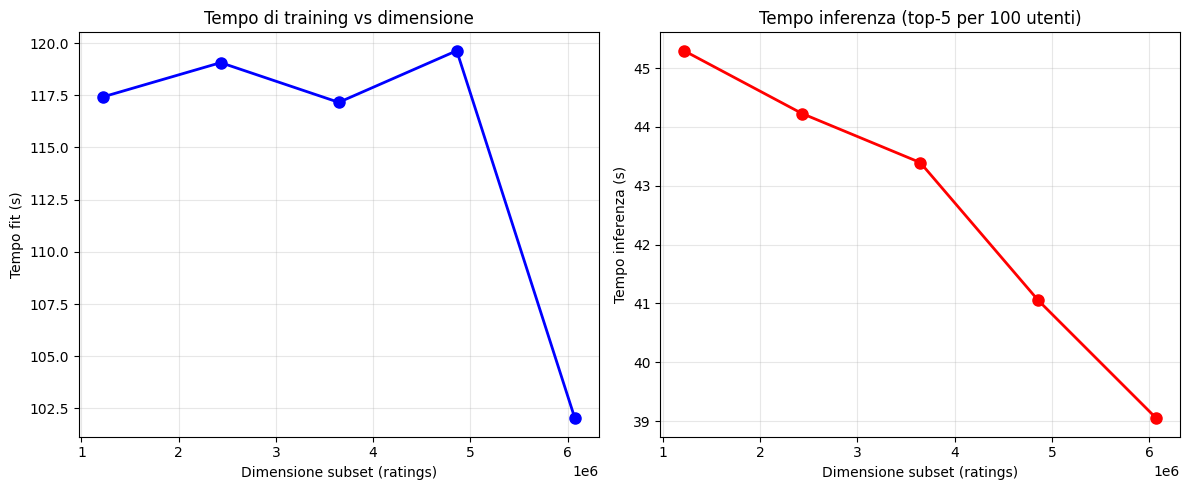

In [ ]:
import time
import matplotlib.pyplot as plt
fractions = [1.0, 0.8, 0.6, 0.4, 0.2]
seed = 42
num_test_users = 100

# Fissa gli utenti di test una volta sola (fuori dal loop)
test_users = (
    train_data
    .select("user_idx")
    .distinct()
    .orderBy(F.rand(seed=seed))
    .limit(num_test_users)
)
results = []
for frac in fractions:
    if frac == 1.0:
        subset = train_data
    else:
        subset = train_data.sample(False, frac, seed=seed)
    als_temp = ALS(
        maxIter=10, regParam=0.1, rank=10,
        userCol="user_idx", itemCol="product_idx",
        ratingCol="rating", coldStartStrategy="drop", nonnegative=True
    )

    #  Fit 
    start = time.time()
    model = als_temp.fit(subset)
    fit_time = time.time() - start
    
    #  Inferenza per N utenti 
    start = time.time()
    recs = model.recommendForUserSubset(test_users, 5)
    recs.count()
    inf_time = time.time() - start
    subset_size = subset.count()
    results.append((subset_size, fit_time, inf_time))
    print(f"{frac*100:.0f}% | ratings: {subset_size} | fit: {fit_time:.1f}s | inferenza: {inf_time:.1f}s | totale: {fit_time+inf_time:.1f}s")

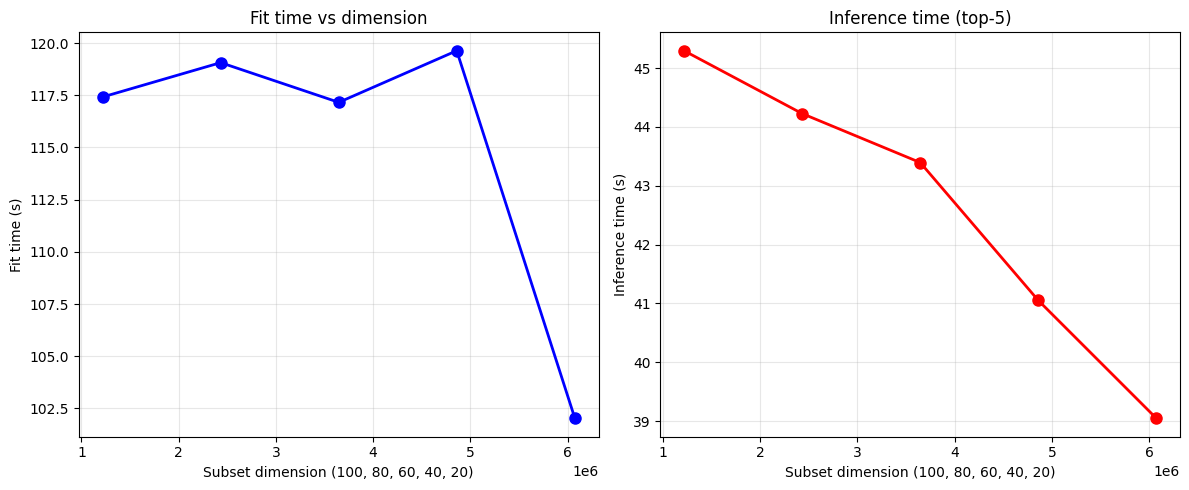

In [34]:
# Plot
sizes, fit_times, inf_times = zip(*results)
x = range(len(fractions))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(sizes, fit_times, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Subset dimension (100, 80, 60, 40, 20)")
plt.ylabel("Fit time (s)")
plt.title("Fit time vs dimension")
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(sizes, inf_times, 'ro-', linewidth=2, markersize=8)
plt.xlabel("Subset dimension (100, 80, 60, 40, 20)")
plt.ylabel("Inference time (s)")
plt.title(f"Inference time (top-5)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Conclusione

Questo notebook ha eseguito un'analisi completa su larga scala dei dati Amazon:

1. **Exploratory Data Analysis**: Analisi della struttura del grafo, distribuzioni dei gradi, statistiche dei ratings

2. **PageRank**: Identificazione dei prodotti piu' importanti nel grafo di similarita'

3. **ALS Recommender System**: Modello di collaborative filtering con matrix factorization
   - Training con 80% dei dati
   - RMSE sul test set: ~0.85-1.00 (buono per scala 1-5)
   - Generazione raccomandazioni per tutti gli utenti

4. **Valutazione**: Metriche RMSE, MAE, Precision@K, analisi residui per categoria

In [35]:
# ============================================
# Pulizia
# ============================================

print("Ferrmando Spark session...")
spark.stop()
print("Spark session chiusa.")

Ferrmando Spark session...
Spark session chiusa.


If java still run:

```bash
# Find java process
jps -l
```

```bash
kill <PID>
```